<a href="https://colab.research.google.com/github/vruddhis/semanticshift/blob/main/notebooks/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import ast
from scipy.spatial.distance import cosine
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [22]:
formal_df = pd.read_csv(
    "all formal words with embeddings.csv",
    engine="python",
    on_bad_lines="skip"
)

informal_df = pd.read_csv(
    "all informal words with embeddings.csv",
    engine="python",
    on_bad_lines="skip"
)


df = pd.concat([formal_df, informal_df], ignore_index=True)


In [23]:
df[["word", "event", "register", "period"]].drop_duplicates().head(40)


,word,event,register,period
0,tag,social-media,formal,before
204,tag,social-media,formal,during
421,tag,social-media,formal,after
630,drop,nft,formal,before
802,drop,nft,formal,during
968,drop,nft,formal,after
1121,model,chatgpt-launch,formal,after
1460,binge,streaming,formal,before
2217,binge,streaming,formal,during
4333,binge,streaming,formal,after


In [24]:
def parse_embedding(x):
    return np.array(ast.literal_eval(x), dtype=np.float32)

df["embedding"] = df["embedding"].apply(parse_embedding)


In [25]:
print(len(df))

16831


In [26]:
grouped = (
    df.groupby(["word", "event", "register", "period"])["embedding"]
      .apply(list)
      .reset_index()
)


In [27]:
def get_embeddings(word, event, register, period):
    row = grouped[
        (grouped.word == word) &
        (grouped.event == event) &
        (grouped.register == register) &
        (grouped.period == period)
    ]
    if len(row) == 0:
        return None
    return row.iloc[0]["embedding"]


In [28]:
def cosine_mean(A, B):
    if len(A) == 0 or len(B) == 0:
        return np.nan
    return cosine(np.mean(A, axis=0), np.mean(B, axis=0))


In [29]:
def apd(A, B):
    if len(A) == 0 or len(B) == 0:
        return np.nan
    return np.mean([cosine(a, b) for a, b in product(A, B)])


In [30]:
def embedding_entropy(A):
    sims = []
    for a, b in product(A, A):
        sims.append(cosine(a, b))
    return np.mean(sims)

def entropy_shift(A, B):
    return embedding_entropy(B) - embedding_entropy(A)


In [31]:
#standard LSC
results = []

for (word, event, register), sub in grouped.groupby(["word", "event", "register"]):

    pre = get_embeddings(word, event, register, "before")
    post = get_embeddings(word, event, register, "after")

    if pre is None or post is None:
        continue

    results.append({
        "word": word,
        "event": event,
        "register": register,
        "cosine_mean": cosine_mean(pre, post),
        "apd": apd(pre, post),
        "entropy_shift": entropy_shift(pre, post)
    })

baseline_df = pd.DataFrame(results)
baseline_df.head()


,word,event,register,cosine_mean,apd,entropy_shift
0,algorithm,ai-automation,formal,0.001989,0.149387,-0.003746
1,binge,streaming,formal,0.048980,0.325761,0.034152
2,bubble,covid-19,formal,0.001584,0.196141,0.011441
3,drop,nft,formal,0.004182,0.238042,-0.009202
4,prompt,chatgpt-launch,formal,0.004121,0.300578,-0.000761


In [32]:
baseline_df[
    ["cosine_mean", "apd", "entropy_shift"]
].corr()


,cosine_mean,apd,entropy_shift
cosine_mean,1.000000,0.327537,0.349119
apd,0.327537,1.000000,-0.217775
entropy_shift,0.349119,-0.217775,1.000000


from matplotlib import pyplot as plt
_df_0['cosine_mean'].plot(kind='hist', bins=20, title='cosine_mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['apd'].plot(kind='hist', bins=20, title='apd')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['entropy_shift'].plot(kind='hist', bins=20, title='entropy_shift')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='cosine_mean', y='apd', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='apd', y='entropy_shift', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5['cosine_mean'].plot(kind='line', figsize=(8, 4), title='cosine_mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_6['apd'].plot(kind='line', figsize=(8, 4), title='apd')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_7['entropy_shift'].plot(kind='line', figsize=(8, 4), title='entropy_shift')
plt.gca().spines[['top', 'right']].set_visible(False)

Prototype movement (cosine) and usage dispersion (APD) overlap partially but measure different phenomena.

This matches literature:

*  Cosine measures dominant sense drift
*  APD measures polysemy / competition between senses

Directional semantic change and contextual diversification are related but not interchangeable.


Contextual spread and semantic separation behave inversely in many cases, highlighting fundamentally different notions of change.

In [33]:
def top_k(metric, k=5):
    return (
        baseline_df
        .sort_values(metric, ascending=False)
        .head(k)[["word", "event", "register", metric]]
    )

top_k("cosine_mean")
top_k("apd")
top_k("entropy_shift")


,word,event,register,entropy_shift
10,tweet,social-media,formal,0.105923
1,binge,streaming,formal,0.034152
8,tag,social-media,formal,0.022052
2,bubble,covid-19,formal,0.011441
6,spoiler,streaming,formal,0.007664


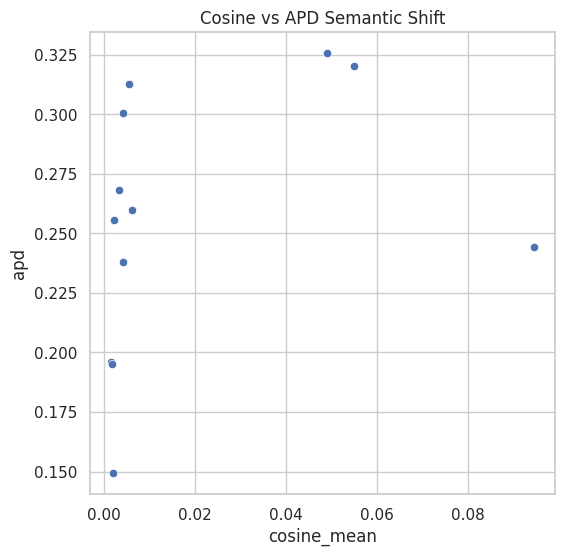

In [36]:


plt.figure(figsize=(6,6))
sns.scatterplot(
    data=baseline_df,
    x="cosine_mean",
    y="apd",
)
plt.title("Cosine vs APD Semantic Shift")
plt.show()


The correlation analysis reveals weak to moderate agreement between standard semantic shift metrics. Cosine distance, which captures movement of the dominant meaning, shows only partial alignment with APD and entropy-based measures. Notably, the negative correlation between APD and entropy shift suggests that increased contextual diversity does not necessarily correspond to greater semantic separation.

These findings indicate that different metrics respond to distinct semantic phenomena, such as dominant sense drift, polysemy dynamics, and contextual spread. As a result, relying on any single metric risks conflating short-term fluctuations with persistent meaning change.


Current semantic shift metrics operate under a binary temporal framing and produce a single scalar score per word, obscuring the underlying causes of change. The observed metric disagreement motivates a structured approach that explicitly models semantic divergence, event-driven perturbation, and register-specific variation.





Semantic change is multi-dimensional; metrics that collapse it into a single distance are inherently incomplete.